# Inputs — Explorando os workloads

In [ ]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

sys.path.insert(0, str(Path.cwd()))

from shared.parser import parse_input
from shared.workload_stats import compute_workload_stats, print_workload_stats

INPUTS_DIR = Path("inputs")
MAIN_WORKLOADS = [INPUTS_DIR / "workload.json", INPUTS_DIR / "workload_simple.json"]
RANDOM_WORKLOADS = sorted(INPUTS_DIR.glob("workload_random_*.json"))

In [ ]:
for path in MAIN_WORKLOADS:
    workload = parse_input(path)
    stats = compute_workload_stats(workload)
    print_workload_stats(stats, title=f"{path.name}")
    print()

┌─────────────────────────────────────────────────────────────┐
│  workload.json                                              │
├─────────────────────────────────────────────────────────────┤
│  Processos                         : 27                     │
│  Tempo médio por processo          : 5.44 ticks  (CPU+E/S)  │
│  Tempo médio de CPU                : 4.07 ticks             │
│  Tempo médio de E/S                : 1.37 ticks             │
│  Tempo mín / máx por processo      : 1 / 11 ticks           │
│  Desvio-padrão do tempo total      : 2.57 ticks             │
│  Bursts médios por processo        : 2.33                   │
│  Chegada média / janela            : 18.52  /  40 ticks     │
│  Demanda total CPU / E/S           : 110 / 37 ticks         │
│  Razão CPU / E/S                   : 2.97                   │
│  Quantum / custo troca de contexto : 5 / 1                  │
└─────────────────────────────────────────────────────────────┘

┌──────────────────────────────────────

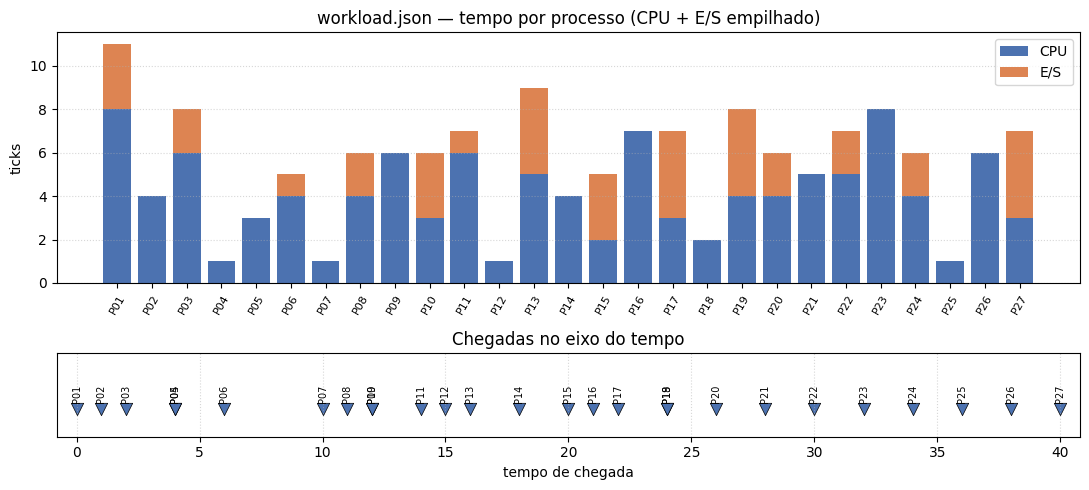

In [ ]:
def plot_workload_anatomy(path, ax_pair=None):
    workload = parse_input(path)
    procs = workload.processes
    pids = [p.pid for p in procs]
    cpu = np.array([p.cpu_total for p in procs])
    io = np.array([p.io_total for p in procs])
    arrivals = np.array([p.arrival for p in procs])

    if ax_pair is None:
        fig, (ax_top, ax_bottom) = plt.subplots(2, 1, figsize=(11, 5),
                                                gridspec_kw={"height_ratios": [3, 1]})
    else:
        ax_top, ax_bottom = ax_pair

    x = np.arange(len(pids))
    ax_top.bar(x, cpu, label="CPU", color="#4c72b0")
    ax_top.bar(x, io, bottom=cpu, label="E/S", color="#dd8452")
    ax_top.set_xticks(x)
    ax_top.set_xticklabels(pids, rotation=60, fontsize=8)
    ax_top.set_ylabel("ticks")
    ax_top.set_title(f"{path.name} — tempo por processo (CPU + E/S empilhado)")
    ax_top.legend(loc="upper right")
    ax_top.grid(axis="y", linestyle=":", alpha=0.5)

    ax_bottom.scatter(arrivals, np.zeros_like(arrivals), marker="v",
                      s=80, color="#4c72b0", edgecolor="black", linewidth=0.5)
    for arr, pid in zip(arrivals, pids):
        ax_bottom.text(arr, 0.15, pid, ha="center", fontsize=7, rotation=90)
    ax_bottom.set_yticks([])
    ax_bottom.set_ylim(-0.5, 1.0)
    ax_bottom.set_xlabel("tempo de chegada")
    ax_bottom.set_title("Chegadas no eixo do tempo")
    ax_bottom.grid(axis="x", linestyle=":", alpha=0.5)
    ax_bottom.margins(x=0.02)

    plt.tight_layout()
    plt.show()


plot_workload_anatomy(INPUTS_DIR / "workload.json")

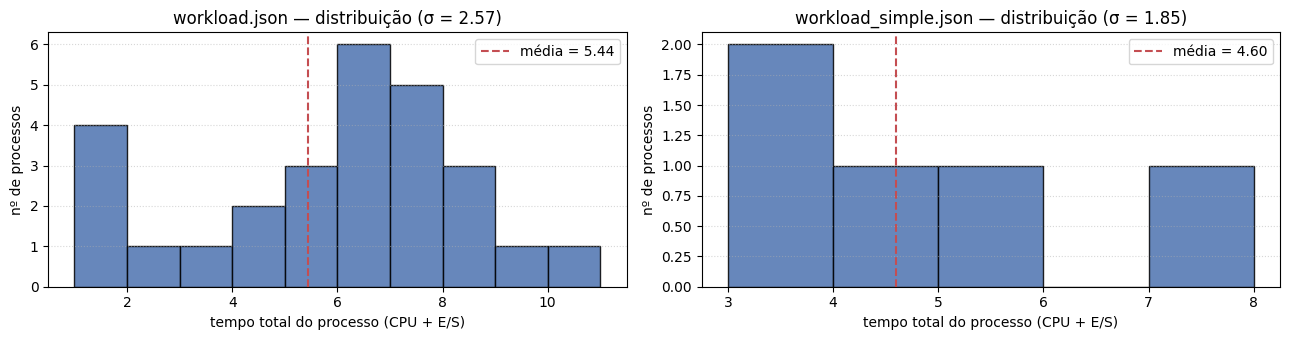

In [ ]:
def plot_time_histogram(path, ax=None):
    workload = parse_input(path)
    totals = [p.cpu_total + p.io_total for p in workload.processes]
    stats = compute_workload_stats(workload)

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 3.5))

    bins = max(5, min(15, len(set(totals))))
    ax.hist(totals, bins=bins, color="#4c72b0", edgecolor="black", alpha=0.85)
    ax.axvline(stats.avg_process_time, color="#c44e52", linestyle="--", linewidth=1.5,
               label=f"média = {stats.avg_process_time:.2f}")
    ax.set_xlabel("tempo total do processo (CPU + E/S)")
    ax.set_ylabel("nº de processos")
    ax.set_title(f"{path.name} — distribuição (σ = {stats.stdev_process_time:.2f})")
    ax.legend()
    ax.grid(axis="y", linestyle=":", alpha=0.5)


fig, axes = plt.subplots(1, 2, figsize=(13, 3.5))
for ax, path in zip(axes, MAIN_WORKLOADS):
    plot_time_histogram(path, ax=ax)
plt.tight_layout()
plt.show()

In [ ]:
random_stats = [(path.name, compute_workload_stats(parse_input(path))) for path in RANDOM_WORKLOADS]

header = ("workload", "n", "avg_total", "avg_cpu", "avg_io", "min", "max", "σ", "cpu/io")
widths = (24, 4, 10, 10, 10, 5, 5, 8, 8)

def fmt_row(values):
    return "  ".join(str(v).ljust(w) for v, w in zip(values, widths))


def ratio_str(s):
    return f"{s.cpu_io_ratio:.2f}" if s.cpu_io_ratio is not None else "—"


print(fmt_row(header))
print("-" * (sum(widths) + 2 * (len(widths) - 1)))
for name, s in random_stats:
    print(fmt_row((
        name,
        s.n_processes,
        f"{s.avg_process_time:.2f}",
        f"{s.avg_cpu:.2f}",
        f"{s.avg_io:.2f}",
        s.min_process_time,
        s.max_process_time,
        f"{s.stdev_process_time:.2f}",
        ratio_str(s),
    )))

workload                  n     avg_total   avg_cpu     avg_io      min    max    σ         cpu/io  
----------------------------------------------------------------------------------------------------
workload_random_01.json   20    48.60       36.45       12.15       5      124    34.78     3.00    
workload_random_02.json   11    43.55       31.00       12.55       4      90     31.73     2.47    
workload_random_03.json   16    33.50       28.31       5.19        4      103    27.38     5.46    
workload_random_04.json   16    48.06       35.94       12.12       7      95     29.28     2.96    
workload_random_05.json   10    54.10       38.20       15.90       8      113    30.58     2.40    
workload_random_06.json   16    63.69       46.69       17.00       10     109    27.78     2.75    
workload_random_07.json   20    55.35       39.05       16.30       7      126    28.13     2.40    
workload_random_08.json   14    63.79       47.00       16.79       21     98     24.21    

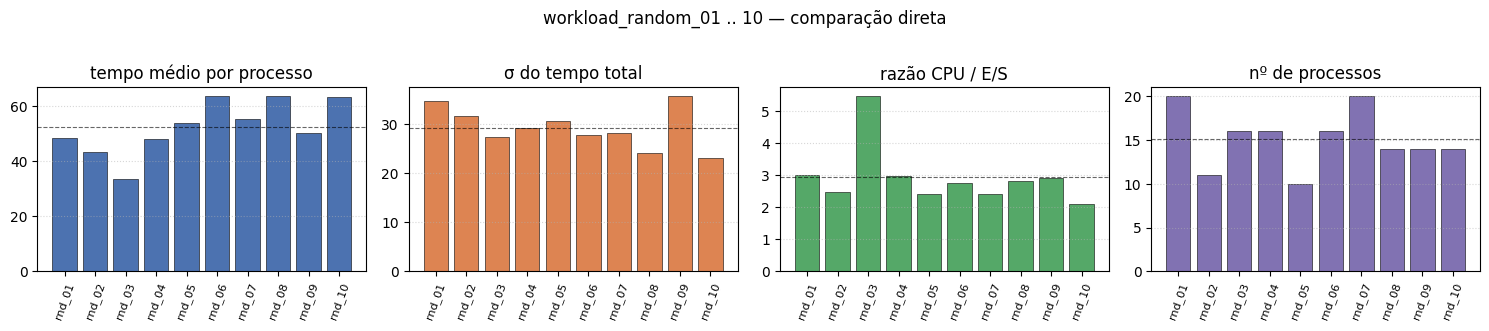

In [ ]:
labels = [name.replace("workload_random_", "rnd_").replace(".json", "") for name, _ in random_stats]
avg_total = [s.avg_process_time for _, s in random_stats]
stdev_total = [s.stdev_process_time for _, s in random_stats]
ratio = [s.cpu_io_ratio if s.cpu_io_ratio is not None else 0.0 for _, s in random_stats]
n_proc = [s.n_processes for _, s in random_stats]

fig, axes = plt.subplots(1, 4, figsize=(15, 3.2))
metrics = [
    (avg_total, "tempo médio por processo", "#4c72b0"),
    (stdev_total, "σ do tempo total", "#dd8452"),
    (ratio, "razão CPU / E/S", "#55a868"),
    (n_proc, "nº de processos", "#8172b2"),
]
for ax, (values, title, color) in zip(axes, metrics):
    ax.bar(labels, values, color=color, edgecolor="black", linewidth=0.4)
    ax.set_title(title)
    ax.tick_params(axis="x", rotation=70, labelsize=8)
    ax.grid(axis="y", linestyle=":", alpha=0.5)
    ax.axhline(np.mean(values), color="black", linestyle="--", linewidth=0.8, alpha=0.6)

fig.suptitle("workload_random_01 .. 10 — comparação direta", y=1.02)
plt.tight_layout()
plt.show()